# 4. Training

Train the Siamese Network with Early Stopping and Checkpoint Management.

**Features:**
- Custom training loop with `@tf.function`
- Early stopping (halts training if validation loss stops improving)
- Checkpoint saving every N epochs
- Metrics: Loss, Precision, Recall
- cluster-compatible (no plotting during training)

## 4.1 Import & Setup

In [1]:
import sys
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
import json

# Project
sys.path.insert(0, str(Path.cwd().parent))
import config
from src import data, models, training, utils

print("✓ Imports successful")
print(f"GPU Available: {len(tf.config.list_physical_devices('GPU')) > 0}")

✓ Imports successful
GPU Available: False


## 4.2 Load Data

In [2]:
print("\nLoading Datasets...\n")

train_data, test_data = data.load_all_datasets(
    str(config.ANCHOR_PATH),
    str(config.POSITIVE_PATH),
    str(config.NEGATIVE_PATH),
    apply_augmentation=True
)

print("\n✓ Datasets loaded")


Loading Datasets...

Lade Anchor Bilder von: C:\Users\angel\Documents\AI Master3.Semester\Doyourecognizeme\data\anchor
  ✓ 400 Anchor Bilder geladen
Lade Positive Bilder von: C:\Users\angel\Documents\AI Master3.Semester\Doyourecognizeme\data\positive
  ✓ 400 Positive Bilder geladen
Lade Negative Bilder von: C:\Users\angel\Documents\AI Master3.Semester\Doyourecognizeme\data\negative
  ✓ 2000 Negative Bilder geladen

Erstelle Triplet Dataset mit On-The-Fly Augmentation...

📊 Dataset Balancing:
  Anchor/Positive Pairs: 400
  Negative Samples:     2000
  Total Pairs per Epoch: 2400
  Anchors repeated 5x for negative pairing
  ✓ Dataset erstellt
Prepariere Train/Test Pipeline...
  ✓ Train Dataset: 105 Batches
  ✓ Test Dataset: 45 Batches

✓ Datasets loaded


## 4.3 Create Model

In [3]:
print("\nCreating Siamese Network...\n")

siamese_model = models.create_siamese_network()
print("✓ Model created")
print(f"\nModel Parameters: {siamese_model.count_params():,}")


Creating Siamese Network...

✓ Model created

Model Parameters: 38,964,545


## 4.4 Train Model

In [4]:
print("\n" + "="*80)
print("START TRAINING")
print("="*80)

history = training.train_model(
    train_data=train_data,
    val_data=test_data,
    model=siamese_model,
    epochs=config.EPOCHS,
    learning_rate=config.LEARNING_RATE,
    checkpoint_dir=str(config.CHECKPOINT_DIR),
    checkpoint_interval=config.SAVE_INTERVAL,
    early_stopping_patience=config.EARLY_STOPPING_PATIENCE,
    verbose=config.VERBOSE_LEVEL
)

print("\n✓ Training finished")


START TRAINING

⚠️ Alte Checkpoints gefunden (5 Dateien)
   Lösche zur Vermeidung von Verwirrung...
   ✓ Gelöscht: siamese_epoch_0005.keras
   ✓ Gelöscht: siamese_epoch_0010.keras
   ✓ Gelöscht: history_epoch_0005.json
   ✓ Gelöscht: history_epoch_0010.json
   ✓ Gelöscht: training_history.json
   → Training startet FRESH (Epoch 1)


START TRAINING
Epochs: 1 - 50
Learning Rate: 0.0001
Batch Size: 16
Early Stopping Patience: 3
Checkpoint Interval: 5


[Epoch 1/50]
Epoch 1 - Training...
Epoch 1 - Validation...
  Loss: 0.436625 | Val Loss: 0.159910
  Precision: 0.2273 | Val Precision: 0.9492
  Recall: 0.0171 | Val Recall: 0.4870

[Epoch 2/50]
Epoch 2 - Training...
Epoch 2 - Validation...
  Loss: 0.143928 | Val Loss: 0.097022
  Precision: 0.9239 | Val Precision: 0.9688
  Recall: 0.5782 | Val Recall: 0.7154

[Epoch 3/50]
Epoch 3 - Training...
Epoch 3 - Validation...
  Loss: 0.081960 | Val Loss: 0.054118
  Precision: 0.9360 | Val Precision: 0.9760
  Recall: 0.8182 | Val Recall: 0.8905

[Epoc

## 4.5 Plot Training History


Plotting Training History...



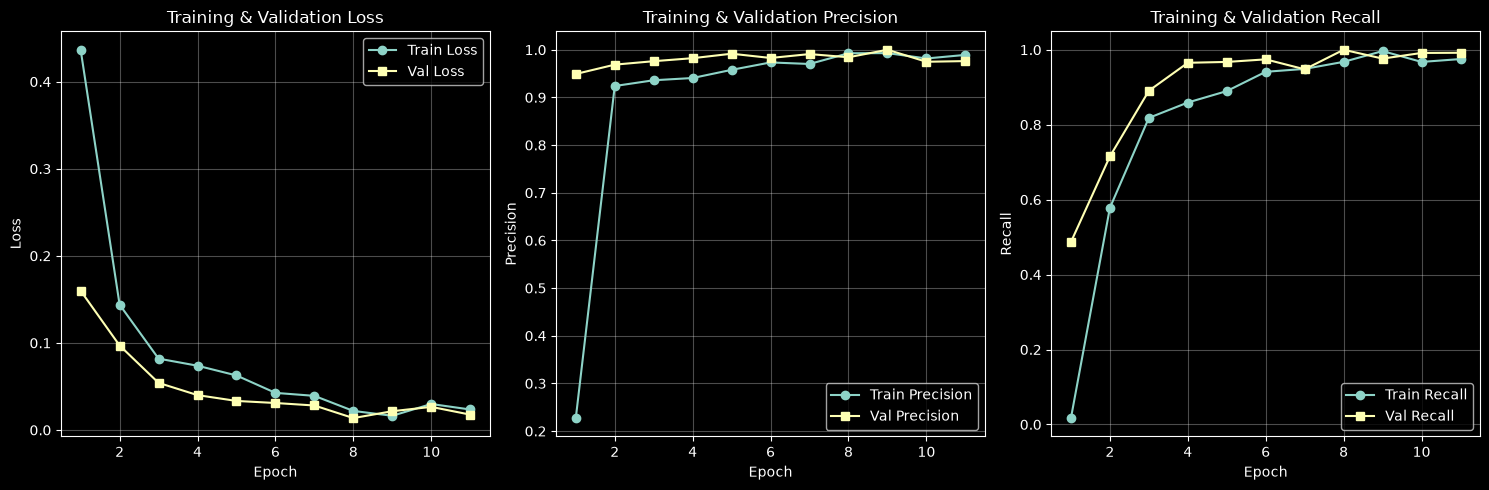


✓ History plotted


In [5]:
print("\nPlotting Training History...\n")

if history.history['epochs']:
    fig = utils.plot_training_history(history.history, figsize=(15, 5))
    plt.tight_layout()
    plt.show()
    print("\n✓ History plotted")
else:
    print(" No history available")

## 4.6 Training Statistics

In [8]:
if history.history['epochs']:
    best_epoch, best_loss = history.get_best_epoch('val_loss')

    print("\n" + "="*80)
    print("TRAINING SUMMARY")
    print("="*80)

    print(f"\n✓ Training Completed:")
    print(f"  Total Epochs: {len(history.history['epochs'])}")
    print(f"  Best Epoch: {best_epoch}")
    print(f"  Best Val Loss: {best_loss:.6f}")

    # Final Metrics
    final_epoch = history.history['epochs'][-1]
    final_idx = -1

    print(f"\n✓ Final Metrics (Epoch {final_epoch}):")
    print(f"  Train Loss: {history.history['train_loss'][final_idx]:.6f}")
    print(f"  Val Loss: {history.history['val_loss'][final_idx]:.6f}")
    print(f"  Train Precision: {history.history['train_precision'][final_idx]:.4f}")
    print(f"  Val Precision: {history.history['val_precision'][final_idx]:.4f}")
    print(f"  Train Recall: {history.history['train_recall'][final_idx]:.4f}")
    print(f"  Val Recall: {history.history['val_recall'][final_idx]:.4f}")

    print(f"\n✓ Checkpoints saved in: {config.CHECKPOINT_DIR}")
    print(f"\n" + "="*80)


TRAINING SUMMARY

✓ Training Completed:
  Total Epochs: 11
  Best Epoch: 8
  Best Val Loss: 0.013690

✓ Final Metrics (Epoch 11):
  Train Loss: 0.023553
  Val Loss: 0.017656
  Train Precision: 0.9892
  Val Precision: 0.9762
  Train Recall: 0.9752
  Val Recall: 0.9919

✓ Checkpoints saved in: C:\Users\angel\Documents\AI Master3.Semester\Doyourecognizeme\checkpoints



## 4.7 Save final Model

In [9]:
# Saving final Modell
final_model_path = str(config.CHECKPOINT_DIR / "siamese_final.keras")
siamese_model.save(final_model_path)
print(f"✓ Finales Model saved: {final_model_path}")

✓ Finales Model saved: C:\Users\angel\Documents\AI Master3.Semester\Doyourecognizeme\checkpoints\siamese_final.keras


## 4.8 Next Steps

In [12]:
print("\n" + "="*80)
print("✓ Notebook 04 - Training completed successfully!")
print("="*80)

print(f"\nNext Steps:")
print(f"1. Notebook 05_evaluation.ipynb: Test the model on test data")

print(f"\nModel Paths:")
print(f"  Final Model: {final_model_path}")
print(f"  Checkpoints: {config.CHECKPOINT_DIR}")
print(f"  History:     {config.CHECKPOINT_DIR / 'training_history.json'}")

print("\n" + "="*80)


✓ Notebook 04 - Training completed successfully!

Next Steps:
1. Notebook 05_evaluation.ipynb: Test the model on test data

Model Paths:
  Final Model: C:\Users\angel\Documents\AI Master3.Semester\Doyourecognizeme\checkpoints\siamese_final.keras
  Checkpoints: C:\Users\angel\Documents\AI Master3.Semester\Doyourecognizeme\checkpoints
  History:     C:\Users\angel\Documents\AI Master3.Semester\Doyourecognizeme\checkpoints\training_history.json

